# Nile Red pixelated wavelength fit

Nile Red is a solvatochromic dye — its emission spectrum shifts with the local
environment's polarity, so its spectral centre of mass reports on local chemistry rather
than just marking a position. `AnalysisPipeline.nile_red.fit_wavelengths_pixelated` bins
localisations onto a spatial grid (default 50 nm cells) and fits a wavelength per
grid cell from the aggregated colour-channel signal — a spatial *map* of local environment,
not a per-molecule identity like `unmix_channels` in the previous notebook.

Data: `test_tiffs/nile_red_example/` — **no raw TIFF** (see its own `README.md`): a
60,000-frame, 0.05 localisations/µm² PAINT acquisition was simulated, fit, and clustered
through the real pipeline, then the raw TIFF discarded to keep the fixture a reasonable
size — only the already-fit `nile_red_example_localisations.h5` (42,176 rows) ships. Two
spatially-separated Nile Red environments were injected (620 nm / 640 nm centre-of-mass
wavelength), deliberately dense/overlapping coverage (no minimum candidate separation,
unlike every other fixture) since the pixelated fit needs several localisations per grid
cell, not isolated single molecules.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pyS3M.AnalysisPipeline import AnalysisPipeline
from pyS3M.Constants import AnalysisConfig
import pyS3M.IOFunctions as IOFunctions
import pyS3M.SpectralFunctions as SpectralFunctions

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "test_tiffs" / "nile_red_example"
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"
LOCS_PATH = DATA_DIR / "nile_red_example_localisations.h5"

cfg = AnalysisConfig(display=False)
pipe = AnalysisPipeline(camera="ximea", config=cfg)
pipe.load_calibration(CALIBRATION_DIR)

locs = IOFunctions.IO_Functions().read_h5_database(str(LOCS_PATH))
print(f"{len(locs)} already-fit, already-clustered localisations loaded directly from disk")

42176 already-fit, already-clustered localisations loaded directly from disk


## Fit

`fit_wavelengths_pixelated` needs:
- the localisations **as an H5 file path** (not a DataFrame in memory) — it reads directly
  from disk, matching the GUI Nile Red panel's "Load Localisations" workflow.
- `camera_parameters`: per-Bayer-channel quantum efficiency curves, from
  `SpectralFunctions.Spectral_Funcs.getpixelefficiency()`.
- `filter_ids`: the emission filter set actually used during acquisition — this fixture
  used exactly the filters below (see its `README.md`); fitting with a different set won't
  recover the injected 620/640 nm split cleanly.
- `aggregate_id_column="molecular_index"`: localisations belonging to the same
  already-clustered molecule are aggregated together rather than treated independently.

In [2]:
R_qe, G_qe, B_qe, wl = SpectralFunctions.Spectral_Funcs(camera=pipe.camera).getpixelefficiency()
camera_parameters = {"pixel_QYs": np.vstack([B_qe, G_qe, R_qe]), "wavelength": wl}

filter_ids = ["semrock-di03-r514-t1-25x36", "semrock-ff01-515-lp", "semrock-ff01-650-200"]
aggregate_id_column = "molecular_index" if "molecular_index" in locs.columns else None

df, grid_info = pipe.nile_red.fit_wavelengths_pixelated(
    str(LOCS_PATH), filter_ids, camera_parameters,
    pixel_size_nm=50.0, wavelength_bounds=(500.0, 750.0), NA=1.49,
    min_localisations=3, aggregate_id_column=aggregate_id_column,
    verbose=True, return_grid=True,
)
print(f"{len(df)} rows fit; {grid_info['wl_grid'].size} grid cells total, "
      f"{np.isfinite(grid_info['wl_grid']).sum()} with a valid wavelength")

42176 rows fit; 33108 grid cells total, 2429 with a valid wavelength


## Histogram — two clear peaks near 620 / 640 nm

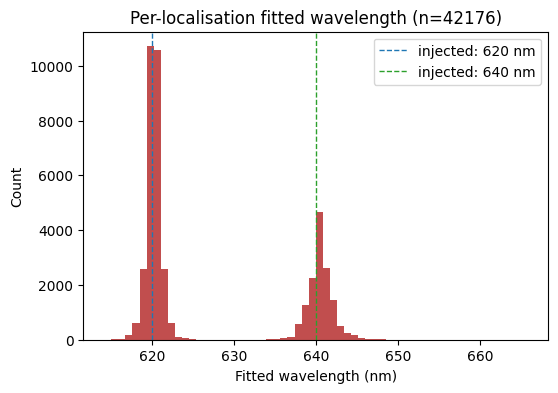

In [3]:
wl_values = df["wl_pixel"].dropna()
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(wl_values, bins=60, color="firebrick", alpha=0.8)
ax.axvline(620, color="tab:blue", ls="--", lw=1, label="injected: 620 nm")
ax.axvline(640, color="tab:green", ls="--", lw=1, label="injected: 640 nm")
ax.set_xlabel("Fitted wavelength (nm)")
ax.set_ylabel("Count")
ax.set_title(f"Per-localisation fitted wavelength (n={len(wl_values)})")
ax.legend()
plt.show()

## Spatial map — two visually distinct environment regions

`grid_info["wl_grid"]` is the pixelated wavelength map itself — rendering it directly as an
image is the right choice here (its cost is fixed by the grid size, not by how many
localisations went in, unlike a per-localisation scatter over this many points).

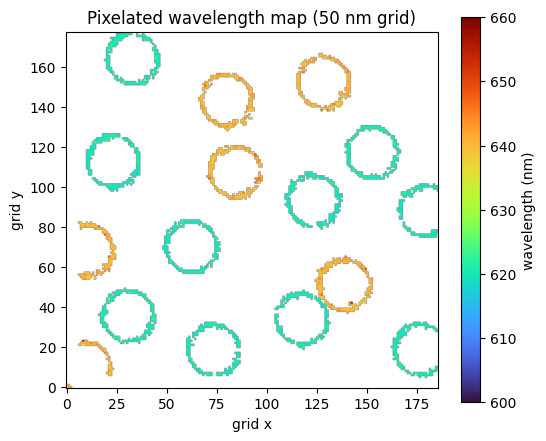

In [4]:
wl_grid = grid_info["wl_grid"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(wl_grid, cmap="turbo", vmin=600, vmax=660, origin="lower")
ax.set_title("Pixelated wavelength map (50 nm grid)")
ax.set_xlabel("grid x")
ax.set_ylabel("grid y")
fig.colorbar(im, ax=ax, label="wavelength (nm)")
plt.show()

## Next: `07_frc.ipynb`

This fixture's dense, repeat-sampled localisations are also the ones `07_frc.ipynb` uses
to demonstrate a genuinely *resolved* FRC curve.